In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:



# ---------- 1. Compute histogram ----------
def compute_histogram(img):
    return np.bincount(img.ravel(), minlength=256)


# ---------- 2. Compute Otsu threshold ----------
def otsu_threshold(hist):
    total_pixels = hist.sum()
    intensity = np.arange(256)

    total_mean = np.sum(intensity * hist)

    sumB = 0.0
    wB = 0.0
    max_var = 0.0
    optimal_threshold = 0

    for t in range(256):
        wB += hist[t]
        if wB == 0:
            continue

        wF = total_pixels - wB
        if wF == 0:
            break

        sumB += t * hist[t]

        mB = sumB / wB
        mF = (total_mean - sumB) / wF

        var_between = wB * wF * (mB - mF) ** 2

        if var_between > max_var:
            max_var = var_between
            optimal_threshold = t

    return optimal_threshold


In [3]:


# ---------- 3. Decide foreground side ----------
def determine_foreground_side(img, threshold):

    above = img >= threshold
    below = img < threshold

    # Heuristic: smaller region = foreground
    if np.sum(above) < np.sum(below):
        foreground_side = True
    else:
        foreground_side = False

    return threshold, foreground_side



In [4]:

# ---------- 4. Main analysis function ----------
def analyze_image(img):
    hist = compute_histogram(img)
    threshold = otsu_threshold(hist)
    threshold, foreground_side = determine_foreground_side(img, threshold)

    return threshold, foreground_side


# ---------- 5. Apply segmentation ----------
def apply_segmentation(img, threshold, foreground_side):
    if foreground_side:
        binary = np.where(img >= threshold, 255, 0)
    else:
        binary = np.where(img < threshold, 255, 0)

    return binary.astype(np.uint8)


Optimal Threshold: 130


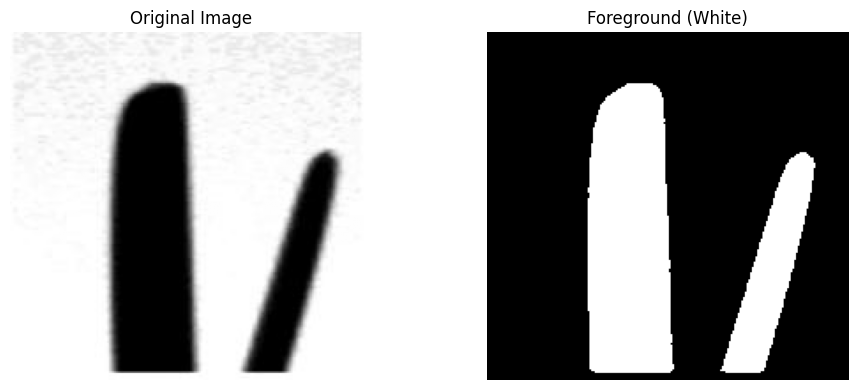

In [5]:


# ---------- 6. Visualization ----------
def plot_results(original, segmented):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Foreground (White)")
    plt.imshow(segmented, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# ---------- Example usage ----------
image = Image.open('/mnt/Personal/Projects/Autofocus/test_images/image/cactus.jpg').convert("L")
img = np.asarray(image)

threshold, fg_side = analyze_image(img)

print("Optimal Threshold:", threshold)

segmented_img = apply_segmentation(img, threshold, fg_side)

plot_results(img, segmented_img)